In [ ]:
import os
import math
import gymnasium as gym  # Import gymnasium and alias it as gym for convenience
from gymnasium import spaces
import numpy as np
import pandas as pd

import geopandas as gpd
from shapely import geometry
from shapely.geometry import LineString, Point
from utils import *
%load_ext autoreload # Load the autoreload extension, which watches imports for changes
%autoreload 2 # Automatically reload any module when its source file changes
pd.set_option('display.max_columns', 100)
from haversine import haversine, Unit
import warnings
warnings.filterwarnings('ignore') # Suppress all warning messages to keep output clean
%load_ext tensorboard # Enable TensorBoard magic for live RL training metrics

In [2]:
featurefile = pd.read_csv('featurefile_transformed_2.csv')
featurefile.head()

,Unnamed: 0,filenames,resolvedflight,flightstarttime_original_res,original_resstart_lat,original_resstart_lon,original_resend_lat,distfrombound_TCP,original_resend_lon,resflight_offset,flightstarttime_original_unres,original_unresstart_lat,original_unresstart_lon,original_unresend_lat,original_unresend_lon,unresflight_offset,initialhead_resolved,initialhead_unresolved,conflict_angle,mantoconflict_dunres,mantoconflict_dres,tcp_direction,unrsolvedflight_dirn,d_bound_manstart,d_bound_CPA,neighbouring_ac,meandistance,timetoresolution,d_resstart_CPA,headingAngle,crosstrack_dist_max,mergewp_name,mergept_TCPdist,resolved_ac,manstrt_time,manstrt_res_lon,mansrtr_res_lat,resflight_CPA_lon,resflight_CPA_lat,unresflight_CPA_lon,unresflight_CPA_lat,maxcrosstrack_time,maxcrosstrack_lon,maxcrosstrack_lat,mergept_time,mergept_lon,mergept_lat,CPA_orig_maneuvered,original_resstart_lat_T,original_resend_lat_T,original_unresstart_lat_T,original_unresend_lat_T,manstart_res_lat_T,maxcrosstrack_lat_T,original_resstart_lon_T,original_resend_lon_T,original_unresstart_lon_T,original_unresend_lon_T,manstart_res_lon_T,maxcrosstrack_lon_T,NAME,LAT,LON,lon_T,lat_T
0,0,170321set1_1_KL01.csv_1_3K00.csv,170321set1_1_KL01.csv,14:00:40,4.57262,106.403,2.50410,19.14,106.548,22,14:02:30,3.72198,107.306,1.60220,103.998,0,170,249,79.82,44.747429,48.740609,-1,-1,4.53,30.28,0,0.00,6.17,46,160,6.13,OMLIV,38.60,farther,14:04:30,106.245,4.14306,106.382,3.38520,106.382,3.38520,14:09:15,106.450,3.57772,14:14:20,106.469,2.93461,6.77,89.3155,37.60250,68.0495,15.05500,78.57650,64.44300,68.06,70.96,86.12,19.96,64.90,69.00,ONAPO,3.353889,106.387778,67.755556,58.847222
1,1,170321set1_1_SQ20.csv_1_QR21.csv,170321set1_1_SQ20.csv,14:14:40,3.72198,107.306,1.60220,21.03,103.998,77,14:21:05,2.52356,106.535,3.18297,104.142,0,249,286,36.36,59.616039,63.374070,-1,-1,37.54,19.74,1,92.54,8.08,61,210,13.65,WP071,78.58,farther,14:24:20,106.169,3.26591,105.220,2.90634,105.220,2.90634,14:27:25,105.955,2.94447,14:37:45,104.670,2.69183,11.12,68.0495,15.05500,38.0890,54.57425,56.64775,48.61175,86.12,19.96,70.70,22.84,63.38,59.10,LIPRO,2.895000,105.190833,43.816667,47.375000
2,2,170321set1_1_QR31.csv_1_3K30.csv,170321set1_1_QR31.csv,14:21:55,3.72198,107.306,3.40823,21.62,103.908,37,14:25:00,4.57262,106.403,2.56699,104.093,0,267,231,36.20,43.565178,49.890922,1,1,36.23,24.73,3,57.40,6.08,46,330,12.32,VISAT,79.24,farther,14:32:15,106.029,3.51914,105.269,3.47690,105.269,3.47690,14:34:30,105.837,3.71123,14:44:55,104.544,3.44267,15.09,68.0495,60.20575,89.3155,39.17475,62.97850,67.78075,86.12,18.16,68.06,21.86,60.58,56.74,MABAL,3.473889,105.209722,44.194444,61.847222
3,3,170321set1_1_KL41.csv_1_TR40.csv,170321set1_1_KL41.csv,14:29:40,4.57262,106.403,2.50410,31.44,106.548,0,14:28:55,4.19994,105.012,2.35462,107.115,9,170,131,37.29,66.980781,60.068521,1,1,13.24,10.51,4,78.15,8.33,62,230,18.20,OMLIV,48.69,closer,14:35:30,106.280,3.89266,106.480,2.86689,106.480,2.86689,14:38:35,106.032,3.60852,14:45:00,106.466,2.92278,6.07,89.3155,37.60250,79.9985,33.86550,72.31650,65.21300,68.06,70.96,40.24,82.30,65.60,60.64,OMLIV,2.919722,106.469722,69.394444,47.993056
4,4,170321set1_1_GA50.csv_1_3K51.csv,170321set1_1_GA50.csv,14:35:10,3.72198,107.306,1.60220,21.36,103.998,83,14:42:05,2.52356,106.535,3.18297,104.142,0,249,286,36.36,57.068835,57.016036,-1,-1,36.44,18.66,3,70.06,7.50,56,210,12.45,WP071,73.51,closer,14:45:40,106.070,3.22811,105.191,2.89499,105.191,2.89499,14:48:30,105.872,2.93408,14:58:10,104.671,2.69216,6.84,68.0495,15.05500,38.0890,54.57425,55.70275,48.35200,86.12,19.96,70.70,22.84,61.40,57.44,LIPRO,2.895000,105.190833,43.816667,47.375000


delta_heading = featurefile['initialhead_resolved'] - featurefile['headingAngle']
delta_heading.unique()

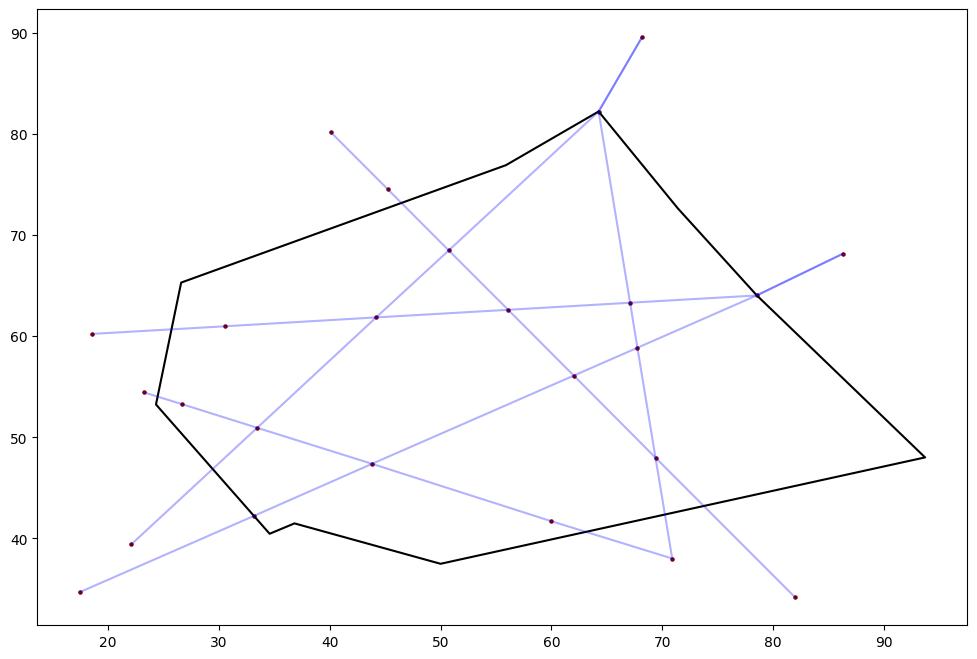

In [3]:
a = plot_sector()

class Ownship:
    def __init__(self, start_x, start_y, heading, speed, offset, original_path, destination):
        self.start_x = start_x
        self.start_y = start_y
        self.x = start_x
        self.y = start_y
        self.offset = offset
        self.heading = heading
        self.speed = speed
        self.offset = offset
        self.destination = destination
        self.pathlist = []
        self.original_path = original_path
        self.position = [self.x, self.y]

    def step(self, n_step, new_heading):
        if n_step <= self.offset:
            self.x = self.start_x
            self.y = self.start_y
        else:    
            self.heading = new_heading
            self.x = np.clip(self.x + self.speed *np.cos(new_heading), 0, 100)
            self.y = np.clip(self.y + self.speed *np.sin(new_heading), 0, 100)
        return self.x, self.y
    
class Intruder:
    def __init__(self, start_x, start_y, offset, heading, speed, destination):
        self.start_x = start_x
        self.stat_y = start_y
        self.x = start_x
        self.y = start_y
        self.offset = offset
        self.heading = heading
        self.speed = speed
        self.destination = destination
        self.position = [self.x, self.y]

    def step(self, n_step, new_heading):
        if n_step <= self.offset:
            self.x = self.start_x
            self.y = self.start_y
        else:
            self.heading = new_heading
            self.x = np.clip(self.x + self.speed *np.cos(new_heading), 0, 100)
            self.y = np.clip(self.y + self.speed *np.sin(new_heading), 0, 100)
        return self.x, self.y


In [ ]:
class Agent():
    """
    The Agent class encapsulates the state and parameters for two aircraft in a conflict scenario: the “ownship” (o_) 
    and the “intruder” (i_). Its __init__ method calls a helper to load all scenario data (paths, headings, start/destination
    points, scaled offsets, etc.) for one scenario from our DataFrame, then organizes that into easy-to-use attributes. It 
    also computes fixed speeds and the number of time-steps to reach each aircraft’s first conflict point (“offset”), and 
    prepares a LineString for the ATCO-approved path.

        # 1) Pull all relevant scenario arrays/values for ownship (o_*) and intruder (i_*).
        #    get_conflict_scenario returns:
        #    - o_resolved_path: list of [x, y] for ATCO-approved ownship route
        #    - o_unres_path:   list of [x, y] for original ownship route before conflict resolution
        #    - o_heading:      initial ownship heading (radians)
        #    - o_startposition:ownship start [x, y]
        #    - o_offset_dist_scaled: distance ownship travels before conflict point (scaled)
        #    - o_destination:  ownship destination [x, y]
        #    - i_path:         intruder path coordinates list
        #    - i_headinglist:  list of heading angles for intruder at each step
        #    - i_startposition:intruder start [x, y]
        #    - i_offset_dist_scaled: intruder’s scaled offset distance
        #    - i_destination:  intruder destination [x, y]
        #    - fileinfo:       metadata about this scenario (e.g., filename, index)
    """
    def __init__(self):
        o_resolved_path, o_unres_path, o_heading, o_startposition, o_offset_dist_scaled, o_destination, \
        i_path, i_headinglist, i_startposition, i_offset_dist_scaled, i_destination, fileinfo = get_conflict_scenario(featurefile)
        # 2) Store ownship’s “resolved” (ATCO-approved) vs. “unresolved” paths
        self.o_resolved_path = o_resolved_path
        self.o_unresolved_path = o_unres_path
        # 3) Initial and current heading for ownship
        self.o_initial_heading = o_heading
        self.o_heading = o_heading
        # 4) Start position (tuple) vs. mutable position list
        self.o_start = tuple(o_startposition)
        self.o_position = o_startposition
        # 5) Distance until conflict (“offset”), scaled for ownship
        self.o_offset_dist = o_offset_dist_scaled
        # 6) Final waypoint for ownship
        self.o_destination = o_destination
        # 7) Record the trajectory we’ll actually fly (starts with the initial point)
        self.o_newpathlist = [self.o_position]
        # 8) Create a geometric LineString of the ATCO-approved path
        self.ATCO_path_linestring = LineString(o_resolved_path)
        # 9) Intruder’s per-step headings and start/position
        self.i_headinglist = i_headinglist
        self.i_start = tuple(i_startposition)
        self.i_position = i_startposition
        # 10) Intruder’s original path, offset distance, and destination
        self.i_path = i_path
        self.i_offset_dist = i_offset_dist_scaled
        self.i_destination = i_destination
        # 11) Fixed speeds for both aircraft (units per time-step)
        self.o_speed = 2
        self.i_speed = 2
        # 12) Number of steps before each reaches the conflict “offset”
        self.o_offset = int(np.ceil(self.o_offset_dist/self.o_speed))
        self.i_offset = int(np.ceil(self.i_offset_dist/self.i_speed))
        # 13) Counter for how many heading changes (“actions”) we’ve applied
        self.n_actions = 0
        # 14) Store scenario metadata for later (e.g., plotting titles)
        self.fileinfo = fileinfo
        # print(self.o_offset, self.i_offset)


    def step(self, n_step, new_heading):
        # Prepare placeholders for new x,y positions
        xo, yo, xi, yi = 0, 0, 0, 0
        # --- Move the ownship ---
        # If we haven’t passed the intruder’s delay yet, keep ownship at its start point
        if n_step <= self.i_offset:
            self.o_position = self.o_start
        else:
            # Otherwise, point the ownship in the new_heading direction    
            self.o_heading = new_heading
            # Move forward by o_speed in the x-direction, then force x inside [15,100]
            xo = np.clip(self.o_position[0] + self.o_speed *np.cos(new_heading), 15, 100)
            # Move forward by o_speed in the y-direction, then force y inside [15,100]
            yo = np.clip(self.o_position[1] + self.o_speed *np.sin(new_heading), 15, 100)
            # xo = self.o_unresolved_path[n_step - self.i_offset][0]
            # yo = self.o_unresolved_path[n_step - self.i_offset][1]

            # Update the ownship’s position
            self.o_position = [xo,yo]
        # Save this ownship point so we can draw its path later    
        self.o_newpathlist.append([xo,yo])

        # print('offset',self.i_offset)
        # Before the ownship’s delay is up, keep intruder at its start  
        if n_step <= self.o_offset:
            self.i_position = self.i_start
        # While the intruder still has heading steps left:
        elif len(self.i_path)+ self.o_offset > n_step > self.o_offset:
            # Move in x by i_speed along that heading, keep x inside [15,100]
            xi = np.clip(self.i_position[0] + self.i_speed *np.cos(self.i_headinglist[n_step - self.o_offset]), 15, 100)
            # Move in y by i_speed along that heading, keep y inside [15,100]
            yi = np.clip(self.i_position[1] + self.i_speed *np.sin(self.i_headinglist[n_step - self.o_offset]), 15, 100)
            # Update the intruder’s position
            self.i_position = [xi, yi]
        else:
            # After the intruder’s whole path is done, jump to its destination
            self.i_position = self.i_destination
        # Return the new ownship and intruder positions
        return self.o_position, self.i_position
        

In [5]:
A = Agent()

In [ ]:
class StructuredEnv(gym.Env):
    """
    This constructor sets up our custom Gym environment. It takes in a list of reward-weight parameters, 
    creates a fresh Agent. It initializes step and reward counters, then defines how many actions are possible 
    and what shape/value-ranges our observations will have. This tells any RL algorithm how to talk to our environment.
    """
    SAFE_R = 5 # Minimum safe separation distance between aircraft
    MAX_STEP = 60 # Maximum number of time-steps per episode

    def __init__(self, Reward_Params= [-1, -1, -1, -1, -1, 1]):
        # 1) Store the list of six reward-component weights (a1…a6)
        self.Reward_Params = Reward_Params
        # 2) Create a new conflict-scenario agent (ownship + intruder)
        self.agent = Agent()
        # 3) Initialize the reward from the last step, the current step counter and the accumulated total reward
        self.reward = 0
        self.n_step = 0
        self.total_reward = 0
        # 4) Determine how many numbers our observation vector will have by calling observation_func once 
        # (it returns a numpy array)
        n_observations = np.size(self.observation_func())
        # 5) Define the action space: 13 discrete choices (turn left/right by various small angles,
        #    or keep heading straight)
        self.action_space = spaces.Discrete(13)
        # 6) Define the observation space: a Box of length n_observations,
        #    with each entry allowed between –100 and +120 
        # is just telling Gym “Expect every observation to be a length-n_observations vector of floats, 
        #  where each float sits between –100 and +120.”      
        self.observation_space = spaces.Box(low = -100, high = 120, shape= (n_observations, ), dtype = np.float64)

    def reset(self, seed=None, options=None):
        """
        The reset method is called at the start of each episode to bring the environment back to its initial state. 
        It optionally seeds randomness, creates a fresh Agent (ownship + intruder), zeroes out all counters 
        and rewards, computes the very first observation, and returns that observation along with an empty info dictionary.
        """
        super().reset(seed=seed) # Call parent reset if you pass seed/options
        # Create a new Agent instance for each reset
        self.agent = Agent() 
        # Initialize counters and rewards, Clear out the last step reward 
        self.reward = 0 
        self.n_step = 0
        self.total_reward = 0
        # Compute the initial observation vector from the fresh agent state
        observation = self.observation_func()
        # Gym’s `reset` requires an `info` dict (we have no extra data to return)
        info = {} 
        # Return the tuple (observation, info)
        # This is the standard return format for Gym environments
        # The observation is the initial state of the environment, and info is an empty dictionary
        return observation, info 

    def step(self, action):
        """
        Given an action (one of 13 discrete turn adjustments), 
        it advances the global time-step, converts that action into a small heading change for the ownship, 
        updates both aircraft positions via the Agent.step call, checks if the episode should end 
        (because both planes reached their goals, came too close, moved away, or exceeded the maximum steps), 
        computes the reward based on all those factors, and finally returns the new observation, the step reward, 
        and flags indicating whether the episode terminated or was truncated.
        """
        # 1) Advance the step counter
        self.n_step += 1
        
        # 2) Prepare termination/truncation flags
        terminated = False
        truncated = False
        # 3) Compute the new ownship heading from the discrete action:
        ownship_heading = self.agent.o_heading
        if action < 7:
            # Actions 0–6 turn right by (action * Δ)
            angle = action * (0.175/2)
        else:
            # Actions 7–12 turn left by ((action - 6) * Δ)
            angle = (action - 6) * -(0.175/2)

        ownship_heading = ownship_heading + angle
        # 4) Move both aircraft one step using the new heading for ownship
        self.agent.step(self.n_step, ownship_heading) # new location for ownship 

        # 5) Measure distances for termination checks:
        #    - First extract the points 
        #    - Ownship to its destination
        #    - Intruder to its destination
        #    - Separation between the two aircraft
        p1 = self.agent.o_position
        o_destination = self.agent.o_destination
        p2 = self.agent.i_position
        i_destination = self.agent.i_destination
        dist1_to_dest = np.linalg.norm(np.array(p1) - np.array(o_destination))
        dist2_to_dest = np.linalg.norm(np.array(p2) - np.array(i_destination))
        sep_dist = np.linalg.norm(np.array(p1) - np.array(p2))

        # 6) Terminate if both reached within 5 units of their goals
        if (dist1_to_dest < 5) and (dist2_to_dest < 5):
            terminated = True
        
        # 7) Terminate if they come closer than SAFE_R (collision risk)
        if (sep_dist < self.SAFE_R):
            terminated = True

        # 8) Terminate if ownship is moving away from its goal by more than a small threshold
        threshold = 0.1
        if len(self.agent.o_newpathlist) > 2: # Ensure there's a previous point to compare
            previous_location = np.array(self.agent.o_newpathlist[-2])
            o_current_location = np.array(self.agent.o_position)
            prev_distance = np.linalg.norm(o_destination - previous_location)
            current_distance = np.linalg.norm(o_destination - o_current_location)
            if prev_distance - current_distance < -threshold:
                terminated = True # Punish for moving away

        # 9) Truncate if we exceed MAX_STEP
        if self.n_step >= self.MAX_STEP:
            truncated = True
        
        # 10) Compute the reward, passing a combined “done” flag
        combined_done_for_reward_func = terminated or truncated
        self.reward = self.reward_func(combined_done_for_reward_func)
        self.total_reward += self.reward
        
        # 11) Build next observation and empty info dict
        observation = self.observation_func()
        info = {}
        # 12) Return the Gym-standard 5-tuple
        return observation, self.reward, terminated, truncated, info # Return 5 values

            
    def reward_func(self, done):
        """ 
        This method computes the scalar reward at each step by combining several components—step penalty, 
        trajectory deviation, loss-of-separation penalty/bonus, failure-to-reach penalty, and success bonus—each 
        weighted by the six parameters a1…a6. If the episode has ended (done=True), additional terms (e.g., whether
        we collided or reached the goal) are applied. The final reward is the weighted sum plus any extra “moving-back” 
        penalty.

        """
        # 1) Unpack the six weights from the environment’s configuration        
        a1 = self.Reward_Params[0]
        a2 = self.Reward_Params[1]
        a3 = self.Reward_Params[2]
        a4 = self.Reward_Params[3]
        a5 = self.Reward_Params[4]
        a6 = self.Reward_Params[5]
        
        # 2) Base costs or rewards (initialized here)
        Reward_Step = 0.01 # small per-step penalty to encourage faster resolution
        Moving_back_reward = 0 # penalty if ownship moves away from its goal
        CTDreward = 0 # placeholder for distance-from-original-path reward (unused)
        reward_traj_dev = 0 # trajectory deviation reward


        # 3) Compute deviation from the ATCO-approved path:
        #    • Create a Point for ownship’s current pos
        #    • Compute its distance to the approved LineString (in same units)
        #    • Scale by 20/1000 to form the deviation reward
        o_destination = np.array(self.agent.o_destination)       
        o_current_location = Point(self.agent.o_position)
        ATCO_path_linestring = self.agent.ATCO_path_linestring
        dist = o_current_location.distance(ATCO_path_linestring)
        reward_traj_dev =  20 * (dist/1000)
        # 4) Combine any CTDreward (currently zero) with the trajectory deviation
        Reward_Deviation = CTDreward +  reward_traj_dev # This is negative, so it penalizes deviation
        
        # 5) Initialize other components
        Reward_LOS = 0
        Reward_Maneuvering = 0
        Reward_Not_Reached = 0
        Reward_Reached =0

        # 6) Distance between ownship and intruder (for LOS/collision)
        dis1 = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.i_position))
        
        Reward_LOS = 0
        threshold = 0.1
        # 7) Only apply certain rewards/penalties once the episode is done
        if done:
            # 7a) Collision or near-miss bonus/penalty: if we ended due to separation breach
            if (dis1 < self.SAFE_R) :
                Reward_LOS = 10 # This is a negative reward, so it penalizes loss of separation

            # 7b) If we reached the maximum number of steps without reaching the destination
            if self.n_step == self.MAX_STEP:
                # Penalize based on how far ownship still is from its destination
                current_location = self.agent.o_position
                dist_o_d = np.linalg.norm(np.array(o_destination) - np.array(current_location))
                Reward_Not_Reached = (dist_o_d/10) # Penalize for not reaching destination

            # 7c) Penalty if the ownship just moved away from its destination in final step (done in the else part)
            if len(self.agent.o_newpathlist) <=2:
                pass
            else:
                # Grab the second-to-last position we recorded for ownship
                previous_location = np.array(self.agent.o_newpathlist[-2])
                # Grab the current position of ownship
                o_current_location = np.array(self.agent.o_position)
                # Compute distance from that previous point to the destination
                prev_distance = np.linalg.norm(o_destination - previous_location)
                # Compute distance from the final point to the destination
                current_distance = np.linalg.norm(o_destination - o_current_location)
                # If current_distance > prev_distance by more than `threshold`,
                # it means ownship moved away. We then set a penalty:
                if prev_distance - current_distance < -threshold:
                    Moving_back_reward =  -20
               

            #reaching destination
            p1 = self.agent.o_position
            o_destination = self.agent.o_destination
            p2 = self.agent.i_position
            
            i_destination = self.agent.i_destination
            # 7d) Success bonus or failure penalty upon reaching ownship destination (else condition)
            dist1 = np.linalg.norm(np.array(p1) - np.array(o_destination))
            # dist2 = np.linalg.norm(np.array(p2) - np.array(i_destination))
            if (dist1 < 5): # reaching destination
                Reward_Reached = 10
            else:
                Reward_Reached = - dist1/10 # penalize for not reaching destination (proportional to remaining distance)

        reward = a1 * Reward_Step + a2 *Reward_Deviation + a3 * Reward_LOS + \
                    a5 * Reward_Not_Reached + a6 * Reward_Reached + Moving_back_reward 
        return reward        


    def observation_func(self):
        """
        This method gathers all the state information we want the agent to “see” at each step,
        packs it into a flat NumPy array, and returns it. It includes the ownship’s and intruder’s positions,
        the ownship’s destination, pairwise distances (between aircraft and to each destination), how far the ownship
        has strayed from its original and ATCO-approved paths, and the ownship’s current heading.

        The observation vector contains, in order:
            Ownship’s X and Y position
            Intruder’s X and Y position
            Ownship’s destination X and Y
            Distance between ownship and intruder
            Distance from ownship to its destination
            Distance from intruder to its destination
            Distance from ownship to its original (unresolved) path
            Distance from ownship to the ATCO-approved path
            Ownship’s current heading angle
        """
        observation  = []

        observation.append(self.agent.o_position[0])
        observation.append(self.agent.o_position[1])
        observation.append(self.agent.i_position[0])
        observation.append(self.agent.i_position[0])
        observation.append(self.agent.o_destination[0])
        observation.append(self.agent.o_destination[1])
        # observation.append(self.agent.i_destination[0])
        # observation.append(self.agent.i_destination[1])
    

        dist1 = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.i_position)) 
        dist_o_d = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.o_destination))
        dist_i_d = np.linalg.norm(np.array(self.agent.i_position) - np.array(self.agent.i_destination))

        # Distance between ownship and intruder
        observation.append(dist1)  
        # Distance from ownship to its destination
        observation.append(dist_o_d)
        # Distance from intruder to its destination
        observation.append(dist_i_d)
        # individual coordinates

        current_location = Point(self.agent.o_position)
        # How far ownship is from its ORIGINAL unresolved path
        CTD_distance  = current_location.distance(LineString(self.agent.o_unresolved_path))
        # How far ownship is from the ATCO-approved path
        dist_from_ATCO_path = current_location.distance(self.agent.ATCO_path_linestring)

        observation.append(CTD_distance) #
        observation.append(dist_from_ATCO_path)

        # Ownship’s current heading angle (radians)
        observation.append(self.agent.o_heading)     
        
        # Convert to a NumPy array and return
        observation = np.array(observation)
        return observation

   
    def render(self, show = False, folder = './Images/'):
        """
        The render method draws a snapshot of the current episode on top of our sector plot, marking both aircraft’s 
        start, current, and destination points, the ATCO-approved path, and safety circles. It can either display the 
        figure interactively or save it to disk. The close method is a no-op placeholder for any future cleanup.
        """
        # fig, ax = plt.subplots(figsize = (14, 11))
        # print("Ownship", self.agent.o_start)
        # print("intruder", self.agent.i_start)
        # print(self.agent.fileinfo)

        # 1) Draw the static sector background
        figure = plot_sector() # Call our helper to redraw boundaries/waypoints
        ax = figure.gca()  # Grab the current Axes for plotting overlays
        # ax.scatter(50,50, s = 200)
        
        # 2)Plot ownship’s current position (black dot), Plot ownship’s start (black triangle), Plot ownship’s destination (black star)
        ax.scatter(self.agent.o_position[0], self.agent.o_position[1], c = 'black', s = 40)
        ax.scatter(self.agent.o_start[0], self.agent.o_start[1] , c = 'black', s = 50, marker = '^')
        ax.scatter(self.agent.o_destination[0], self.agent.o_destination[1], c = 'black', s = 20, marker= '*')

        # 3) Plot intruder’s current position (maroon dot), Plot intruder’s start (maroon triangle), Plot intruder’s destination (maroon star)
        ax.scatter(self.agent.i_position[0], self.agent.i_position[1], c = 'maroon', s = 40)
        ax.scatter(self.agent.i_start[0], self.agent.i_start[1] , c = 'maroon', s = 50, marker = '^')
        ax.scatter(self.agent.i_destination[0], self.agent.i_destination[1], c = 'maroon', s = 20, marker= '*')
        x, y = [],[]
        for i in range(len(self.agent.o_unresolved_path)):
            x.append(self.agent.o_unresolved_path[i][0])    
            y.append(self.agent.o_unresolved_path[i][1])
            
        # ax.plot(x,y, linewidth = 1, color = 'grey')
        #add circle to the destination
        
        # 4) Draw the ATCO-approved path as a dashed maroon line
        x_, y_ = self.agent.ATCO_path_linestring.xy
        ax.plot(x_, y_, color = 'maroon',linestyle = '--', alpha = 1)

        # 5) Add translucent safety circles around each destination
        circle1 = plt.Circle((self.agent.o_destination[0], self.agent.o_destination[1]), 5, color = 'black',\
                              alpha = 0.2)
        circle2 = plt.Circle((self.agent.i_destination[0], self.agent.i_destination[1]), 5, color = 'maroon',\
                              alpha = 0.5)
        ax.add_patch(circle1)
        ax.add_patch(circle2)
        # 6) Annotate title with step number, recent reward, totals, headings, and offsets
        ax.set_title("Step {} - Reward {:.3f} - Total Reward {:.3f} - headings{}  - offsets(O:I){}".format(self.n_step,self.reward,\
                                                                            self.total_reward,\
                                                                                ((self.agent.o_initial_heading) ,\
                                                                                     np.round(math.degrees(self.agent.o_heading),2)),\
                                                                                        (self.agent.o_offset, self.agent.i_offset)))

        # ax.axis('scaled')
        
        # 7) Display the plot or save it to a file
        if show:
            plt.show()
        else:
            # Save the plot as a PNG file named by step number
            plt.savefig(folder + "image_{:0>3}.png".format(self.n_step)) 
            print(folder + "image_{:0>3}.png".format(self.n_step))

        return figure

    def close(self):
        # Placeholder for any cleanup (e.g., closing files or windows). Currently does nothing.
        pass

In [7]:
from stable_baselines3.common.env_checker import check_env
env = StructuredEnv()
check_env(env)

./Images/image_000.png


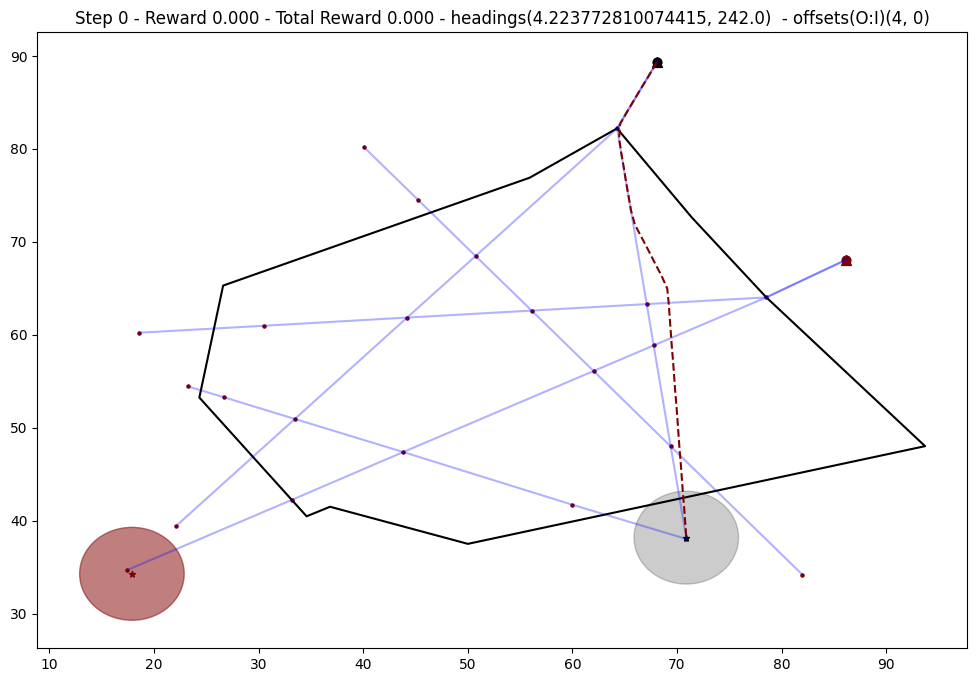

In [ ]:
# Quick smoke test: reset, render one frame, then close3 
env.reset() # Reset the environment to its initial state
env.render() # Draw and save the first frame
env.close() # Close the environment (no-op here, but good practice)

In [ ]:
# Sanity check: print the observation vector shape and values
env.observation_func()

array([6.80600000e+01, 8.93007500e+01, 8.61200000e+01, 8.61200000e+01,
       7.08800000e+01, 3.81737500e+01, 2.78886935e+01, 5.12047120e+01,
       7.61394235e+01, 6.92064196e-03, 0.00000000e+00, 4.22377281e+00])

Reusing TensorBoard on port 8030 (pid 747558), started 8 days, 1:34:10 ago. (Use '!kill 747558' to kill it.)

Overview of the Training & Evaluation Pipeline
This final section shows how we hook our custom environment into Stable-Baselines3’s PPO agent, train it, save the model, evaluate its performance, generate rollout animations, and finally launch TensorBoard to visualize training metrics.

In [ ]:
# 1) Import PPO and related utilities from Stable-Baselines3
from stable_baselines3.ppo import MlpPolicy
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
import glob
from PIL import Image

In [12]:
os.path.exists('./savedmodels/')


True

In [ ]:
# Define a name and reward configuration for this training run
name = 'env_PPO_25july_afternooon'
# 6 weights for the reward function:
Reward_Params= [-1, -1, -1, -1, -1, 1]

# Create the PPO agent, pointing it to our env and enabling TensorBoard logs
model = PPO(MlpPolicy, env ,gamma=0.99, tensorboard_log='./Log/CustomEnv/')
# Set up periodic evaluation during training, saving the best model
eval_env = env # Use the same environment for evaluation
eval_callback = EvalCallback(eval_env, best_model_save_path='./log/PPO/',
                             log_path='./log/PPO/', eval_freq=5000, # Test the policy every 5000 steps
                             deterministic=True, render=False) # Use the greedy policy for evaluation, don't render during eval
# Kick off training for 5 million time-steps, with our callback and a TensorBoard run name
model.learn(total_timesteps= 5000000, tb_log_name=name, callback=eval_callback)

# Ensure our model directory exists (no-op if it already does)
model.save("./savedmodels/" + name) 

# Run a quick offline evaluation of the saved policy
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

Eval num_timesteps=5000, episode_reward=-19.86 +/- 5.81
Episode length: 14.80 +/- 4.49
New best mean reward!
Eval num_timesteps=10000, episode_reward=-23.49 +/- 4.50
Episode length: 10.00 +/- 1.67
Eval num_timesteps=15000, episode_reward=-16.24 +/- 3.97
Episode length: 22.00 +/- 4.98
New best mean reward!
Eval num_timesteps=20000, episode_reward=-14.46 +/- 0.63
Episode length: 19.20 +/- 2.64
New best mean reward!
Eval num_timesteps=25000, episode_reward=-20.42 +/- 5.17
Episode length: 24.40 +/- 4.72
Eval num_timesteps=30000, episode_reward=-20.96 +/- 5.57
Episode length: 21.00 +/- 10.81
Eval num_timesteps=35000, episode_reward=-16.42 +/- 3.78
Episode length: 17.60 +/- 4.22
Eval num_timesteps=40000, episode_reward=-16.10 +/- 3.54
Episode length: 21.20 +/- 4.66
Eval num_timesteps=45000, episode_reward=-16.57 +/- 3.74
Episode length: 20.40 +/- 5.31
Eval num_timesteps=50000, episode_reward=-14.28 +/- 0.12
Episode length: 18.40 +/- 1.96
New best mean reward!
Eval num_timesteps=55000, episod

In [ ]:
# Load back the best checkpoint found during training
model = PPO.load('./log/PPO/best_model.zip')

./images2/image_001.png
./images2/image_002.png
./images2/image_003.png
./images2/image_004.png
./images2/image_005.png
./images2/image_006.png
./images2/image_007.png
./images2/image_008.png
./images2/image_009.png
./images2/image_010.png
./images2/image_011.png
./images2/image_012.png
./images2/image_013.png
./images2/image_014.png
./images2/image_015.png
./images2/image_016.png
./images2/image_017.png
./images2/image_018.png
./images2/image_019.png
./images2/image_020.png
./images2/image_021.png
./images2/image_022.png
./images2/image_023.png
./images2/image_024.png
./images2/image_025.png
./images2/image_026.png
./images2/image_027.png
./images2/image_028.png


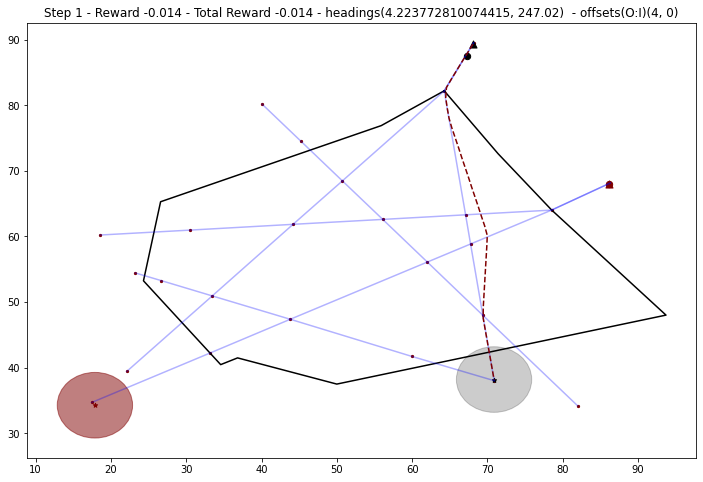

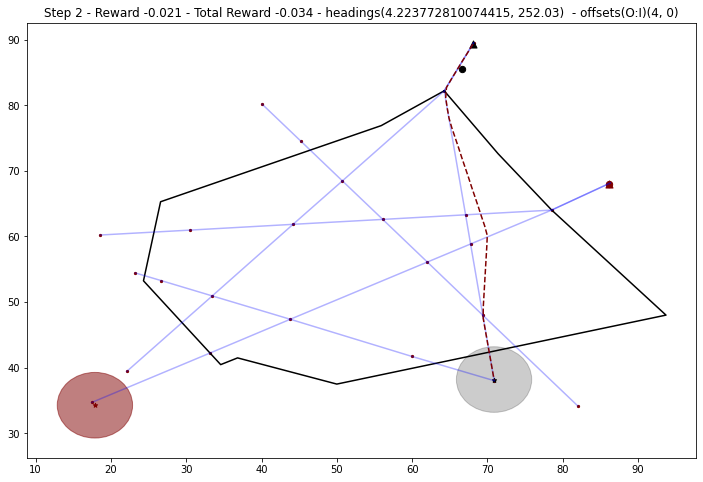

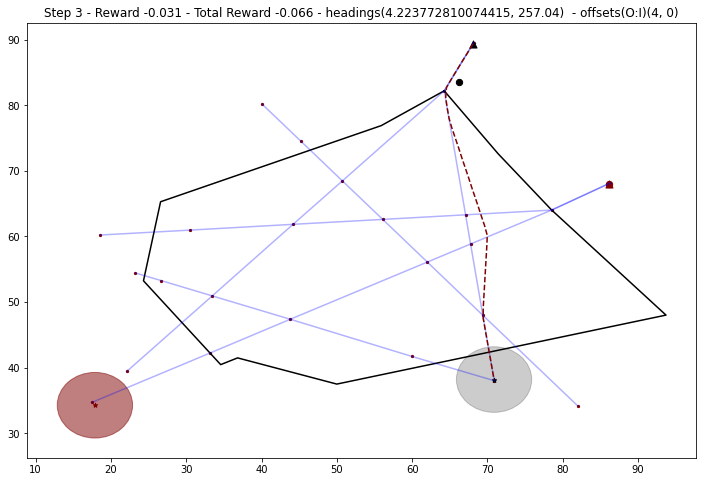

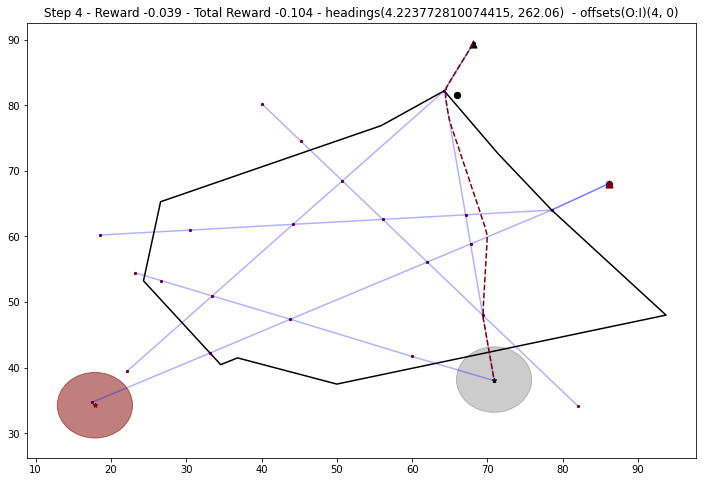

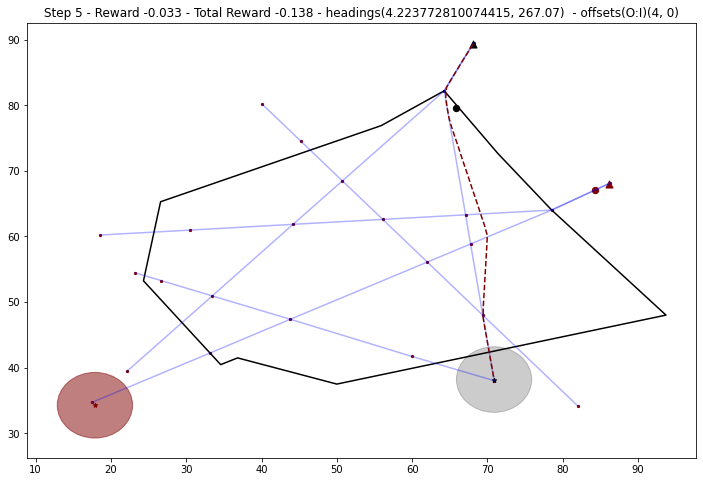

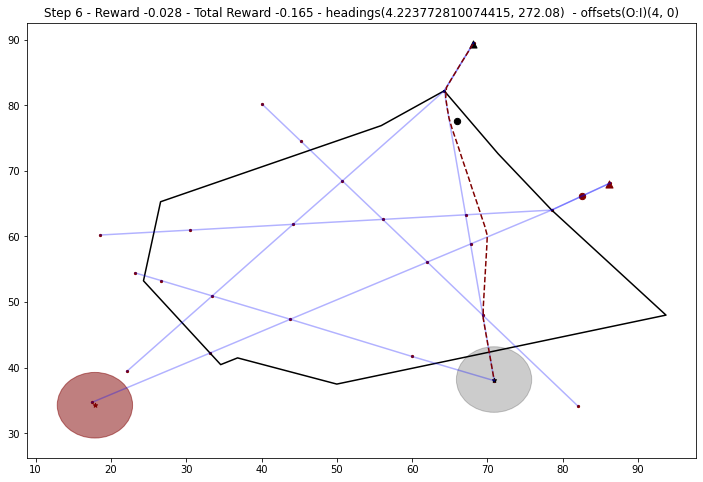

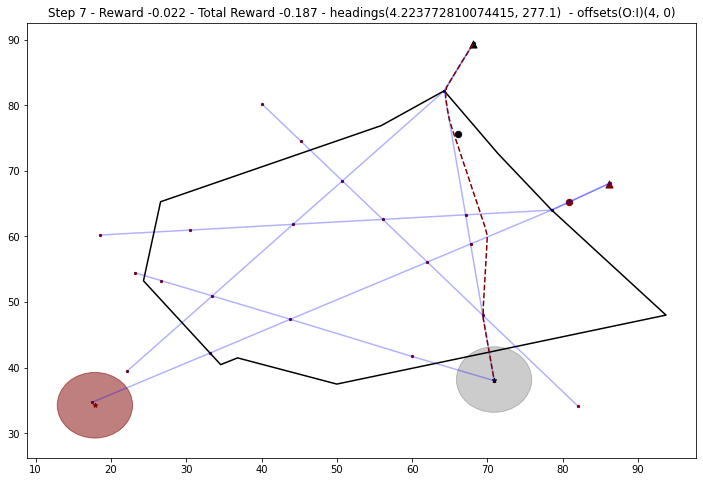

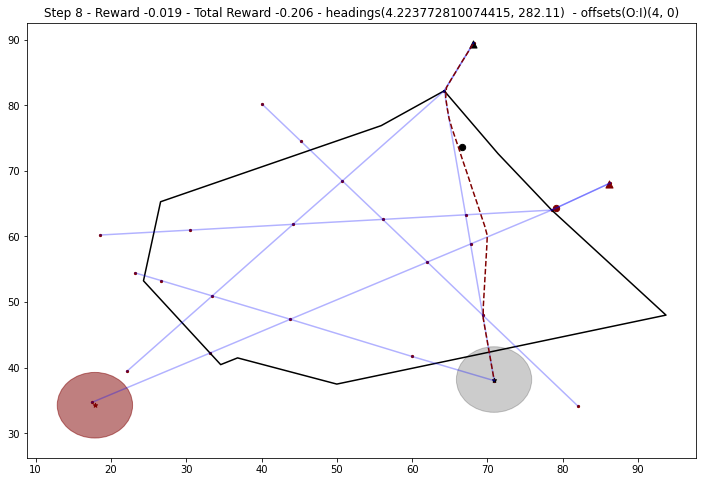

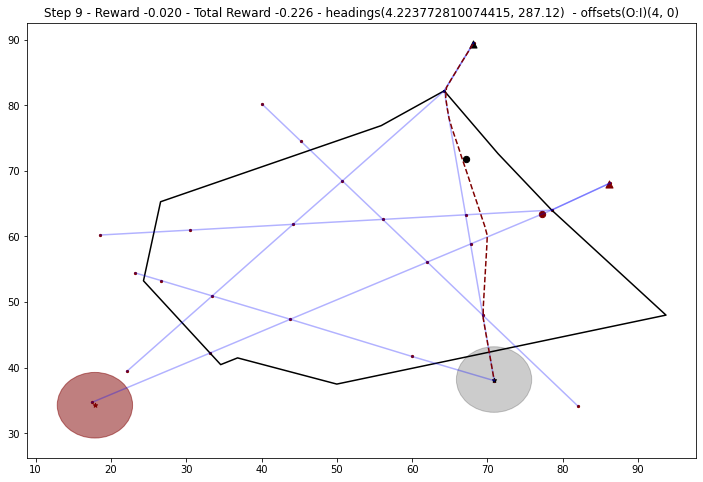

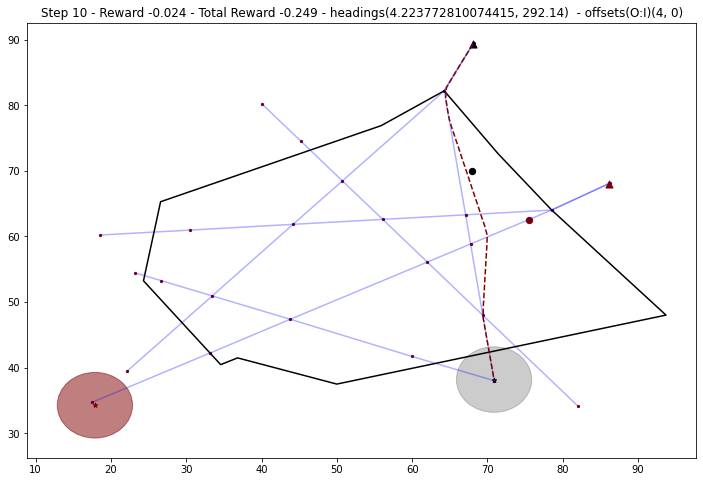

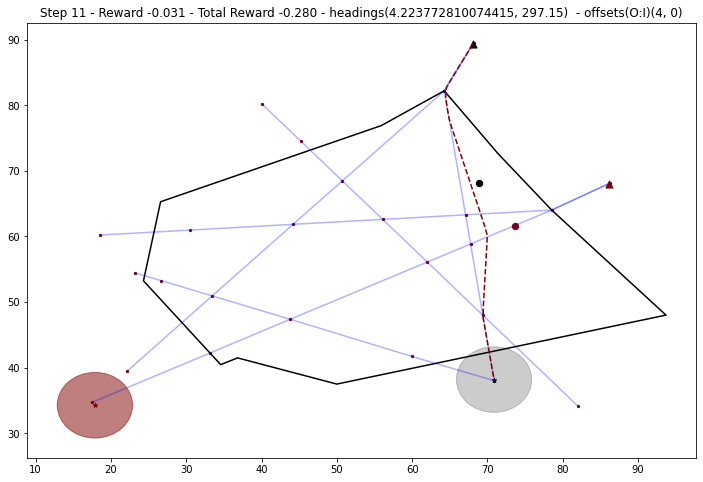

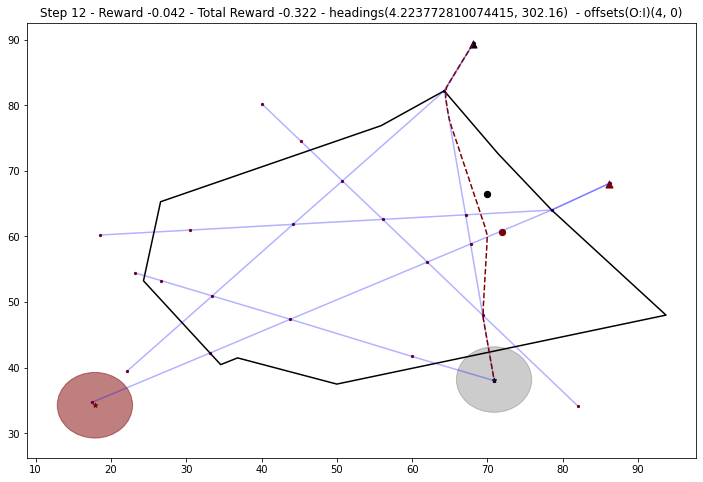

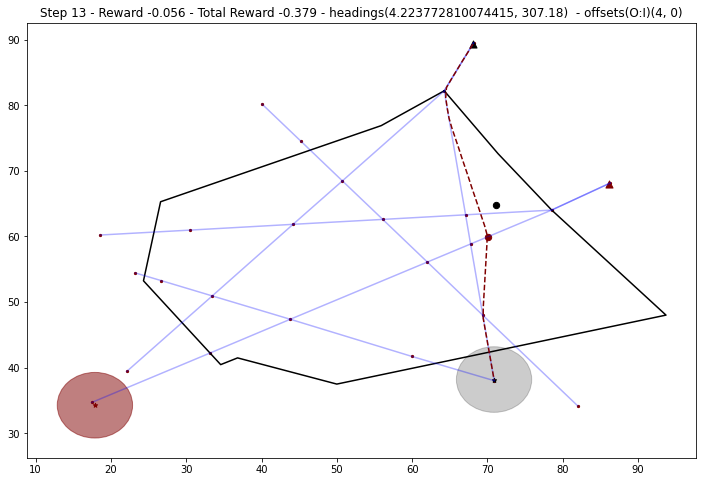

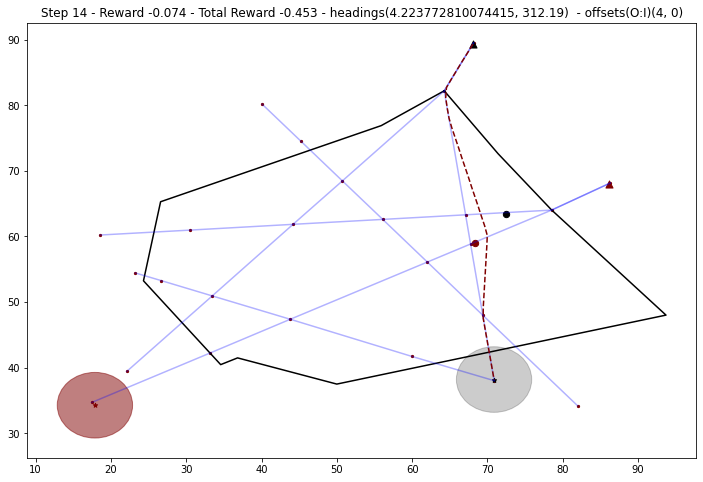

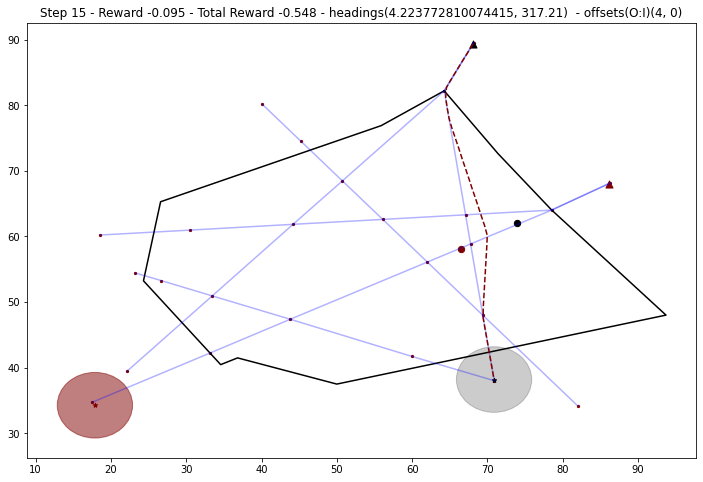

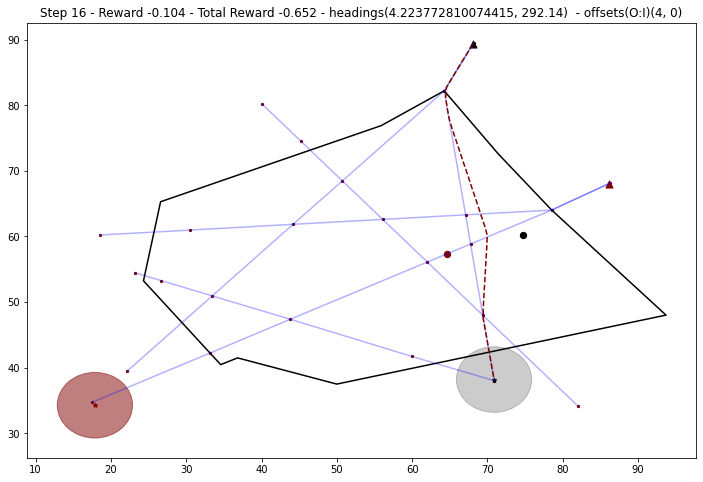

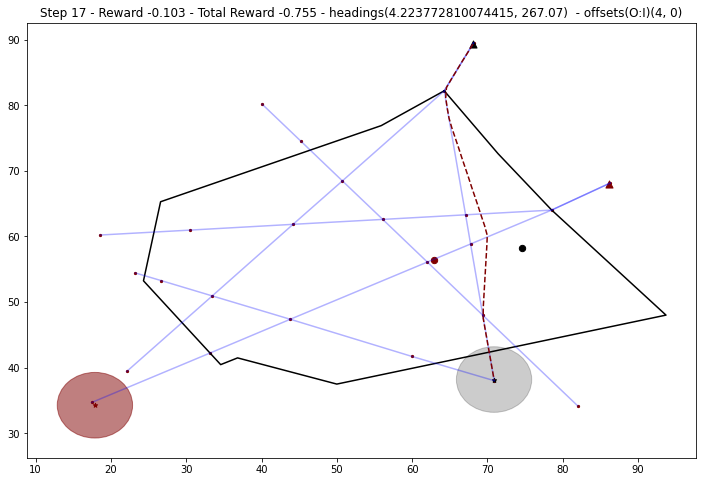

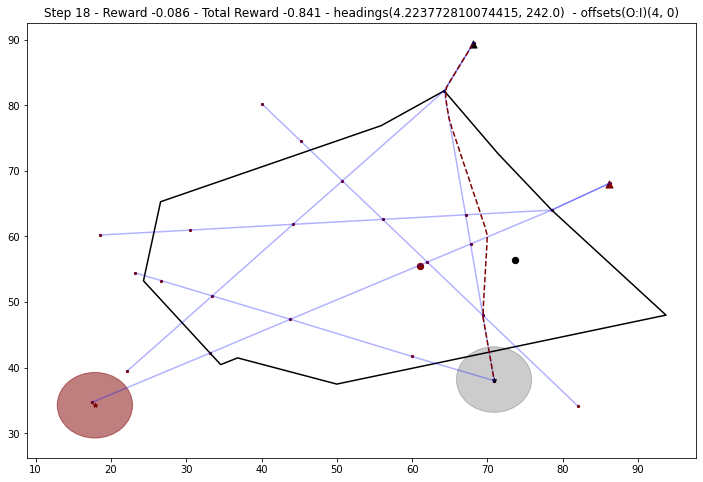

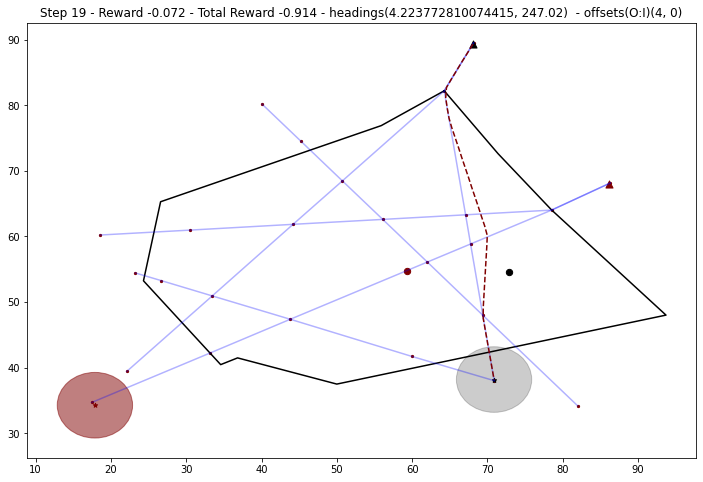

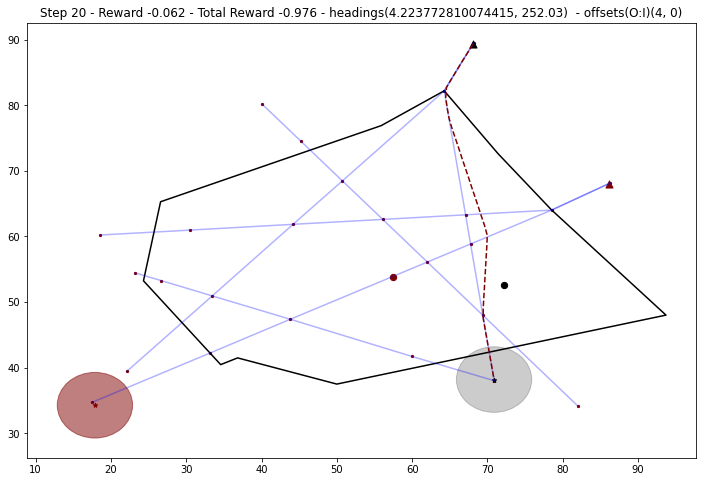

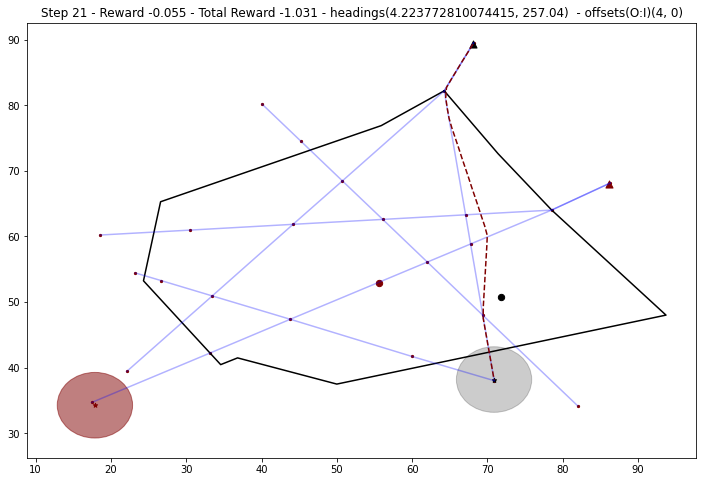

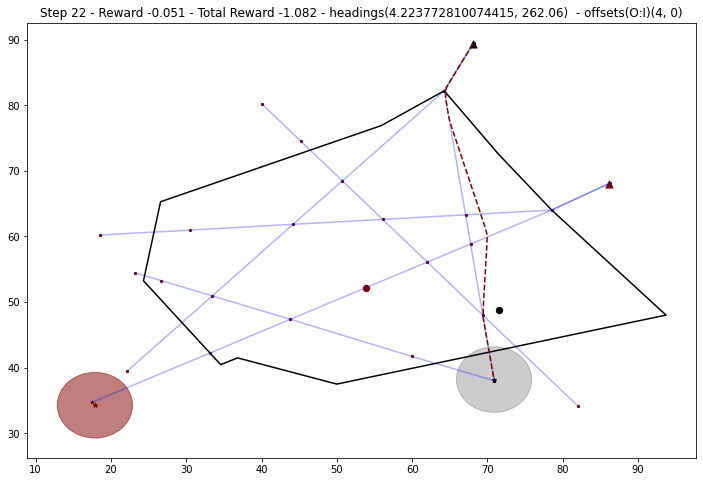

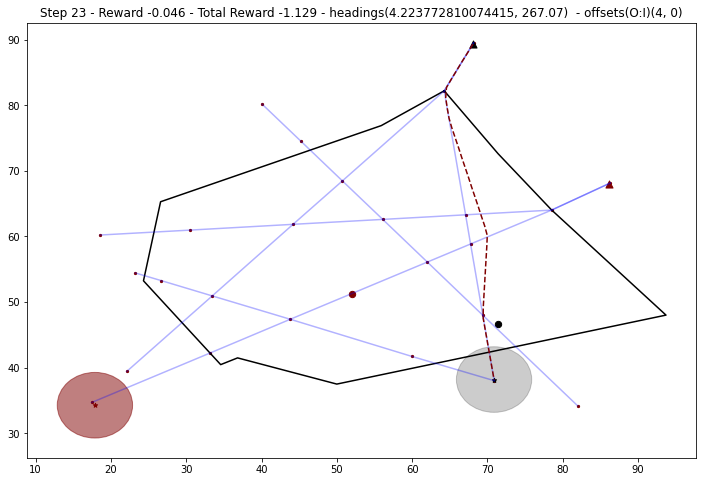

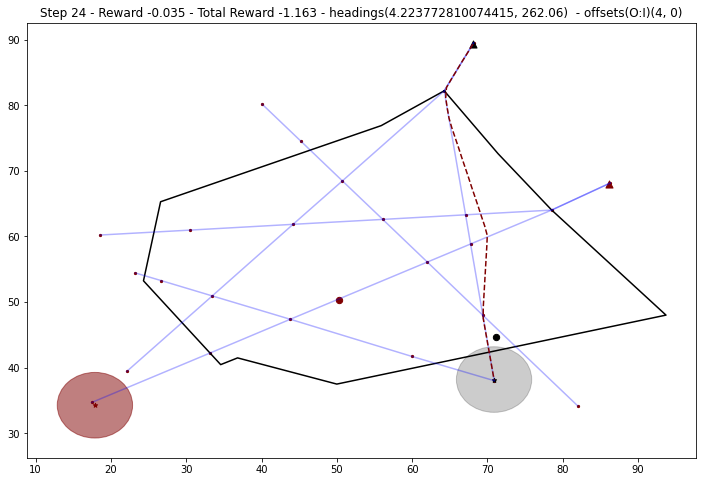

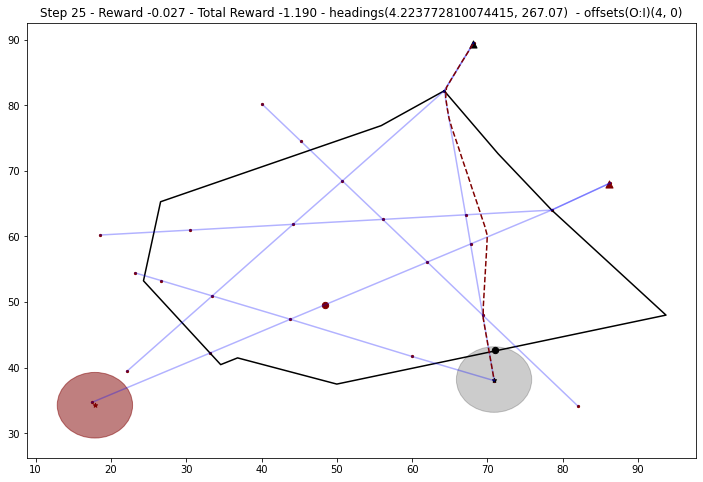

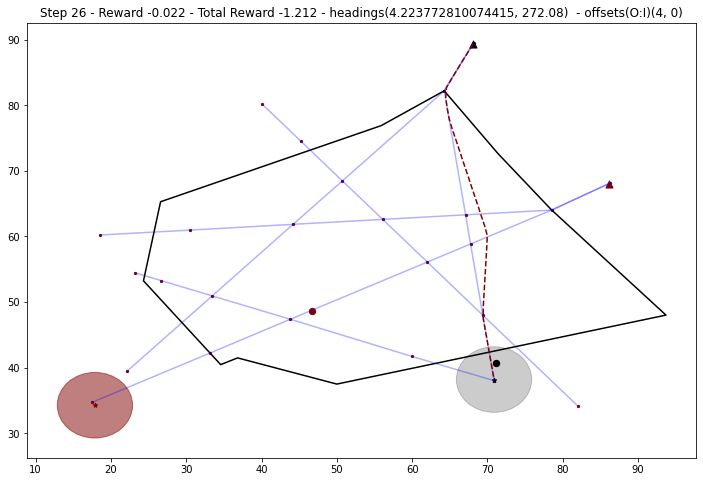

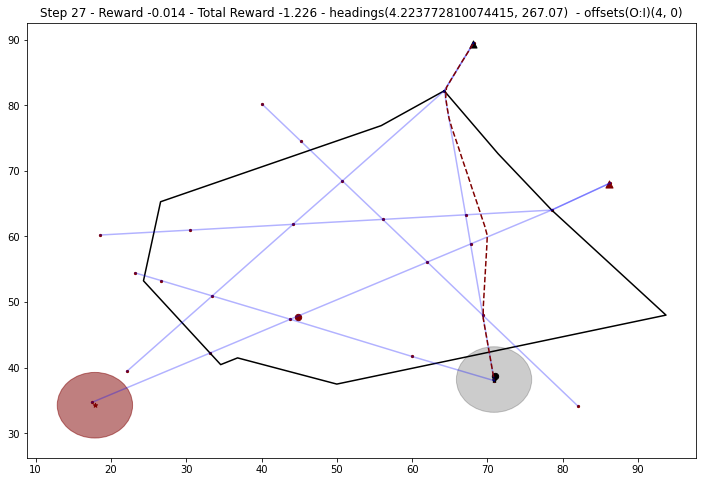

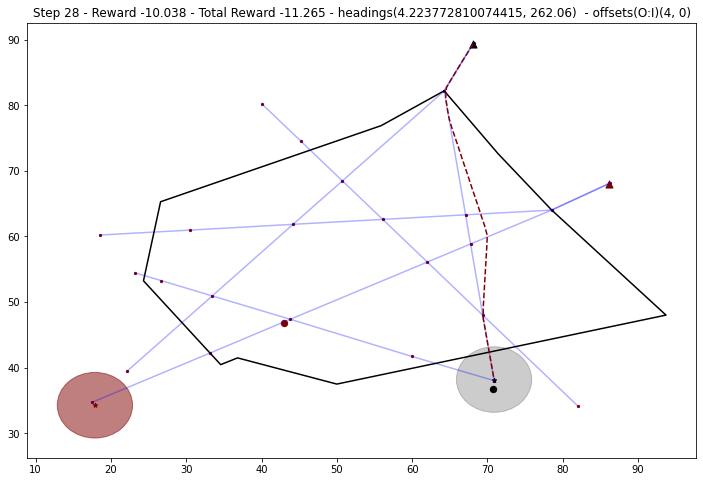

In [ ]:
name = 'env_PPO_24july6'

env  = env # (reuse the same env instance)
obs = env.reset() # Reset the environment to its initial state, reset now returns just the initial observation, unpack just obs
# Perform one rollout with rendering to images
for i in range(60): # Up to 60 steps or until done
    # Take a random action
    action, state_ = model.predict(obs, deterministic=True)
    # action = 0
    obs, reward, done, info = env.step(action)
    
    # Render the game
    c = env.render(False,'./images2/')
    if done == True:
        break
        

# Assemble saved PNGs into a GIF for easy visualization
fp_in = "./images2/image_*.png"
fp_out = "./images2/{}.gif".format(name)

imgs = []
for f in sorted(glob.glob(fp_in)):
    imgs.append(Image.open(f))
    os.remove(f) # Clean up each PNG after loading
    
img = imgs[0]  # extract first image from iterator
# Save the animated GIF with one frame per saved image
img.save(fp=fp_out, format='GIF', append_images=imgs,
         save_all=True, duration=len(imgs)*10, loop=0)

 CHECKING THE PERCENTAGE OF SCENARIOS HAVING CONFLICTS
env = env
 Visualize 1 episode using the trained policy and store the image into selected folder
res = []
for trial in range(100):
    obs = env.reset()
    for i in range(60):
        # Take a random action
        action = 0
        obs, reward, done, info = env.step(action)
        
        # Render the game
        if done == True:
            if reward <= -5:
                res.append(1)
            else:
                res.append(0)
            break

res = np.mean(res)
print('res', res)

In [ ]:
# Launch TensorBoard to view training logs (run in a Jupyter/IPython cell)
%tensorboard --logdir ./Log/ResidualPPO/ --host localhost --port 8040

UsageError: Line magic function `%tensorboard` not found.
